# Feature Analysis and Selection Using Correlation and Mutual Information

## Import Required Libraries for Feature Selection and Visualization

In [1]:
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Processed Data and Computing Pearson Correlation Matrix

In [2]:
# Load the processed feature and target datasets
df_X = pd.read_csv("C:\\Users\\Alyso\\Documents\\ITESM\\Semesters\\8th\\Desarrollo de Aplicaciones Avanzadas\\proyecto_cesvi\\AI-Collision-Speed-Estimation\\model\\data\\CSV\\dataset_V2\\tabular_features.csv")
df_y = pd.read_csv("C:\\Users\\Alyso\\Documents\\ITESM\\Semesters\\8th\\Desarrollo de Aplicaciones Avanzadas\\proyecto_cesvi\\AI-Collision-Speed-Estimation\\model\\data\\CSV\\dataset_V2\\tabular_target.csv")

# Combine features and target into a single DataFrame
df = pd.concat([df_X, df_y], axis=1)

# Compute the Pearson correlation matrix
corr = df.corr(method="pearson")

## Heatmap Visualization of Pearson Correlation Between Features

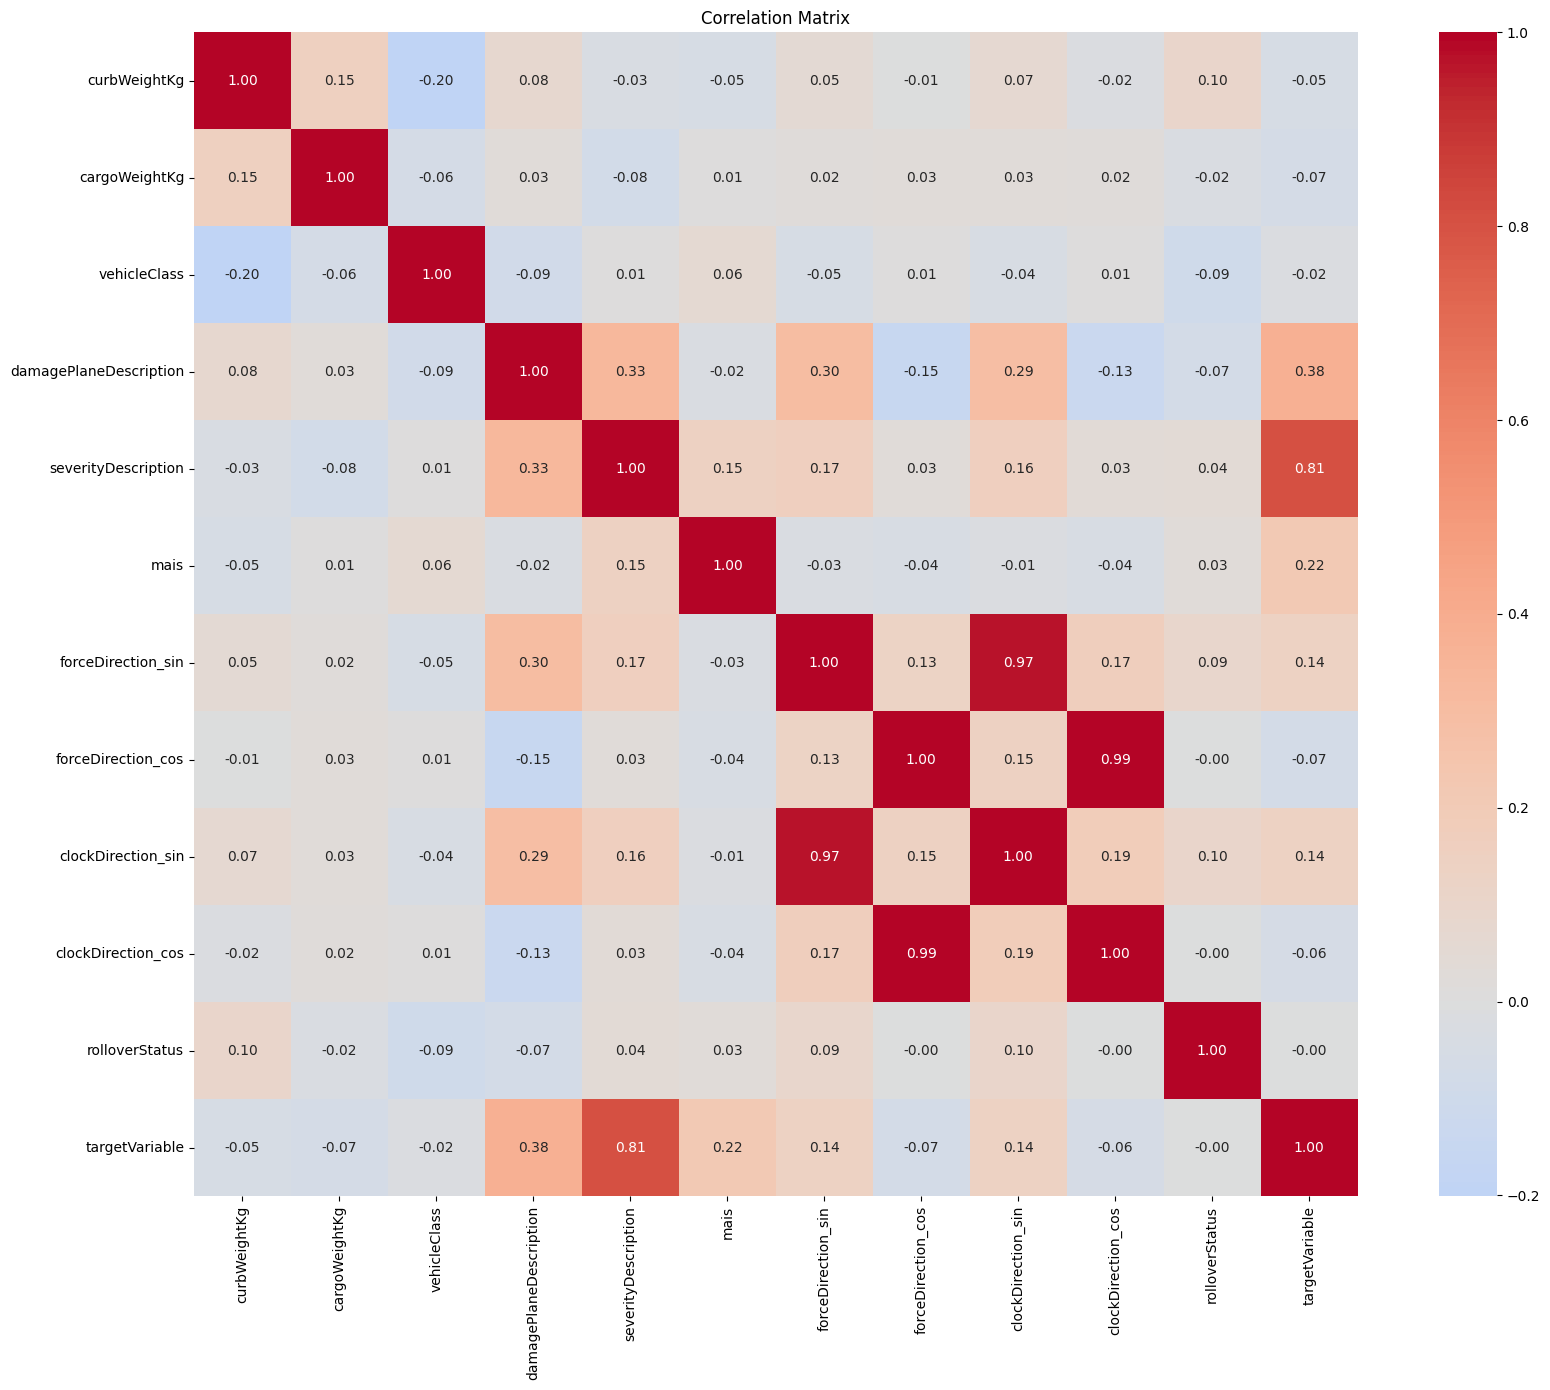

In [3]:
# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr,
    annot=True,      # Display correlation coefficients inside each cell
    fmt=".2f",       # Format values to two decimal places
    cmap="coolwarm", # Use a diverging color palette
    center=0,        # Center the colormap at zero
    square=True      # Make each cell square-shaped
)

# Add title and adjust layout
plt.title("Correlation Matrix")
plt.tight_layout()

# Display the plot
plt.show()

## Evaluating Feature Relevance with Mutual Information Regression

In [4]:
y = df_y.squeeze()

# Compute mutual information scores
mi_scores = mutual_info_regression(
    df_X,
    y,
    random_state=42
)

# Create results table
mi_df = pd.DataFrame({
    "Feature": df_X.columns,
    "Mutual Information": mi_scores
})

display(
    mi_df.sort_values(
        by="Mutual Information",
        ascending=False
    ).style
    .format({"Mutual Information": "{:.4f}"})
    .background_gradient(
        subset=["Mutual Information"],
        cmap="YlGnBu"
    )
)

,Feature,Mutual Information
4,severityDescription,1.0512
6,forceDirection_sin,0.2633
8,clockDirection_sin,0.1519
0,curbWeightKg,0.1338
3,damagePlaneDescription,0.1291
7,forceDirection_cos,0.1219
9,clockDirection_cos,0.1158
5,mais,0.0251
2,vehicleClass,0.0186
1,cargoWeightKg,0.0000


## Comparing Feature Correlation and Mutual Information with the Target

In [5]:
target_name = df_y.columns[0]

comparison = pd.DataFrame({
    "Correlation": corr[target_name].drop(target_name),
    "Mutual Information": mi_scores
}, index=df_X.columns)

display(
    comparison.sort_values(
        by="Mutual Information",
        ascending=False
    ).style
    .format({
        "Correlation": "{:.4f}",
        "Mutual Information": "{:.4f}"
    })
    .background_gradient(
        subset=["Correlation", "Mutual Information"],
        cmap="YlGnBu"
    )
)

,Correlation,Mutual Information
severityDescription,0.8077,1.0512
forceDirection_sin,0.1391,0.2633
clockDirection_sin,0.1407,0.1519
curbWeightKg,-0.0466,0.1338
damagePlaneDescription,0.3790,0.1291
forceDirection_cos,-0.0697,0.1219
clockDirection_cos,-0.0579,0.1158
mais,0.2205,0.0251
vehicleClass,-0.0159,0.0186
cargoWeightKg,-0.0677,0.0000
